In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from ugdatalab.methods.cannon import CannonModel, train_cannon, fit_labels_batch
from ugdatalab.models.apogee.constants import LABEL_NAMES, LABEL_LATEX
from ugdatalab.models.isochrones import _get_mist_isochrone

import plotters

In [2]:
# Load training spectra and cannon model
spec_data = np.load("training_spectra.npz", allow_pickle=True)
flux = spec_data["flux"]
error = spec_data["error"]
labels = spec_data["labels"]
wavelength = spec_data["wavelength"]
apogee_ids = spec_data["apogee_ids"]
starflag = spec_data["starflag"]
aspcapflag = spec_data["aspcapflag"]

model_data = np.load("cannon_model.npz", allow_pickle=True)
train_idx = model_data["train_idx"]
cv_idx = model_data["cv_idx"]

model = CannonModel(
    theta=model_data["theta"],
    scatter=model_data["scatter"],
    label_names=list(model_data["label_names"]),
    label_means=model_data["label_means"],
    label_stds=model_data["label_stds"],
    wavelength=model_data["wavelength"],
    chi2_r=float(model_data["chi2_r"]),
)

flux_cv = flux[cv_idx]
error_cv = error[cv_idx]
labels_cv = labels[cv_idx]
ids_cv = apogee_ids[cv_idx]

print(f"Cannon model: chi2_r = {model.chi2_r:.3f}")
print(f"CV set: {len(cv_idx)} stars")

Cannon model: chi2_r = 1.043
CV set: 943 stars


## Problem 9 — Cross-Validation

### Fit labels on the CV set

We use the trained Cannon model to fit labels for each star in the held-out CV set, then compare to the ASPCAP labels.

In [3]:
fitted_labels = fit_labels_batch(model, flux_cv, error_cv)
print(f"Fitted labels shape: {fitted_labels.shape}")

Fitting labels:   0%|          | 0/943 [00:00<?, ?it/s]

Fitted labels shape: (943, 5)


### 1-to-1 label recovery

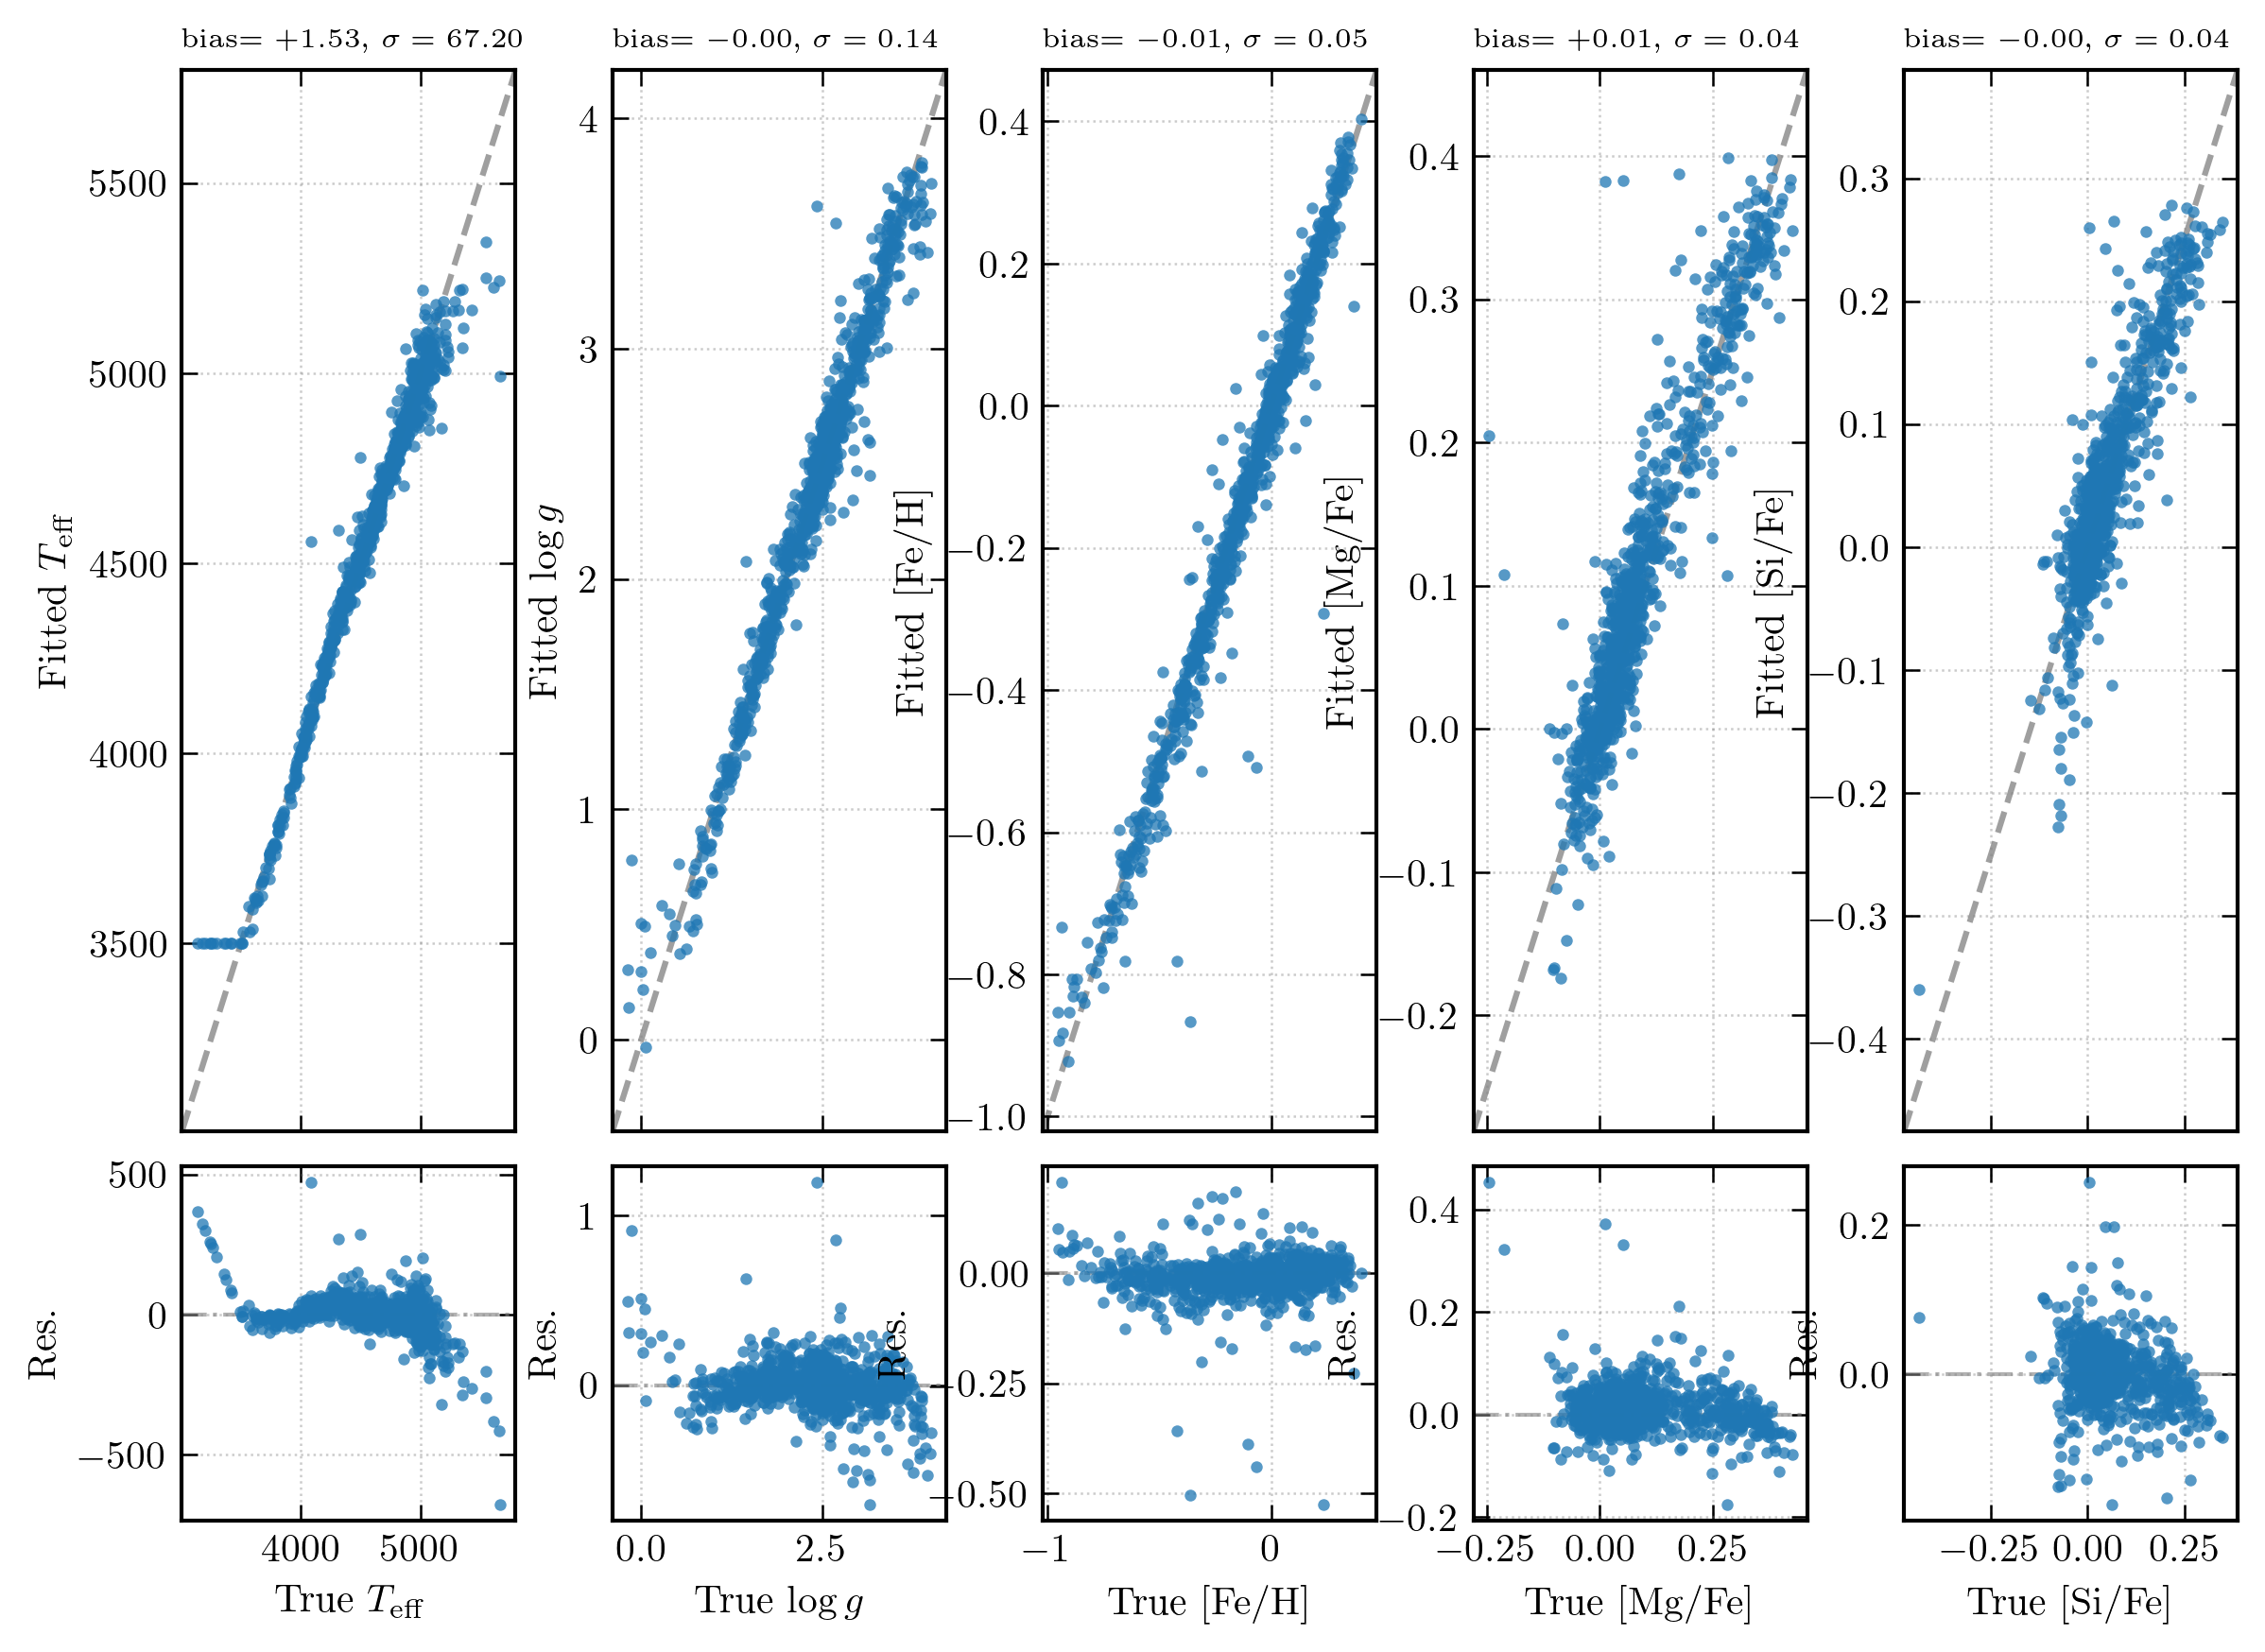

In [4]:
axes = plotters.plot_label_recovery(labels_cv, fitted_labels, LABEL_LATEX)
plt.show()

### Bias and scatter table

In [5]:
residuals = fitted_labels - labels_cv
bias = np.mean(residuals, axis=0)
scatter = np.std(residuals, axis=0)

bias_scatter = pd.DataFrame({
    "Label": LABEL_NAMES,
    "Bias (mean offset)": bias,
    "Scatter (std)": scatter,
})
bias_scatter

,Label,Bias (mean offset),Scatter (std)
0,TEFF,1.528925,67.203871
1,LOGG,-0.000861,0.138409
2,FE_H,-0.007791,0.049610
3,MG_FE,0.011481,0.043395
4,SI_FE,-0.000512,0.039850


### Outlier rejection and re-training

We flag stars whose fitted labels deviate by more than $3\sigma$ (in any single label) from the true labels, remove them from both the training and CV sets, then re-train the Cannon and re-fit. This removes stars with unreliable ASPCAP labels or poor spectra that would degrade model quality.

In [6]:
# Flag outliers: any label residual > 3 * CV scatter
threshold_sigma = 3.0
label_scatter = np.std(residuals, axis=0)
outlier_mask = np.any(np.abs(residuals) > threshold_sigma * label_scatter, axis=1)
n_outliers_cv = np.sum(outlier_mask)

# Map outlier CV indices back to full-dataset indices, then remove from both sets
outlier_full_idx = cv_idx[outlier_mask]
clean_mask = np.ones(len(flux), dtype=bool)
clean_mask[outlier_full_idx] = False

# Also check training set: fit training labels and remove outliers there too
fitted_train = fit_labels_batch(model, flux[train_idx], error[train_idx])
train_resid = fitted_train - labels[train_idx]
train_scatter = np.std(train_resid, axis=0)
train_outlier = np.any(np.abs(train_resid) > threshold_sigma * train_scatter, axis=1)
outlier_train_idx = train_idx[train_outlier]
clean_mask[outlier_train_idx] = False

n_removed = np.sum(~clean_mask)
print(f"Outliers removed: {n_outliers_cv} from CV + {np.sum(train_outlier)} from train = {n_removed} total")
print(f"Clean dataset: {np.sum(clean_mask)} stars (from {len(flux)})")

# Re-split the clean dataset using the same seed
clean_indices = np.where(clean_mask)[0]
rng_clean = np.random.default_rng(seed=42)
perm = rng_clean.permutation(len(clean_indices))
n_train_clean = len(clean_indices) // 2

train_idx_clean = np.sort(clean_indices[perm[:n_train_clean]])
cv_idx_clean = np.sort(clean_indices[perm[n_train_clean:]])

print(f"Clean training: {len(train_idx_clean)}, Clean CV: {len(cv_idx_clean)}")

Fitting labels:   0%|          | 0/943 [00:00<?, ?it/s]

Outliers removed: 43 from CV + 49 from train = 92 total
Clean dataset: 1794 stars (from 1886)
Clean training: 897, Clean CV: 897


In [7]:
model_clean = train_cannon(
    flux[train_idx_clean], error[train_idx_clean], labels[train_idx_clean],
    wavelength, label_names=list(LABEL_NAMES),
)
print(f"Clean model chi2_r: {model_clean.chi2_r:.3f} (was {model.chi2_r:.3f})")

Clean model chi2_r: 1.060 (was 1.043)


In [8]:
fitted_clean = fit_labels_batch(model_clean, flux[cv_idx_clean], error[cv_idx_clean])
residuals_clean = fitted_clean - labels[cv_idx_clean]

comparison = pd.DataFrame({
    "Label": LABEL_NAMES,
    "Before bias": np.mean(residuals, axis=0),
    "Before scatter": np.std(residuals, axis=0),
    "After bias": np.mean(residuals_clean, axis=0),
    "After scatter": np.std(residuals_clean, axis=0),
})
comparison

Fitting labels:   0%|          | 0/897 [00:00<?, ?it/s]

,Label,Before bias,Before scatter,After bias,After scatter
0,TEFF,1.528925,67.203871,-0.826737,49.005508
1,LOGG,-0.000861,0.138409,-0.007898,0.111451
2,FE_H,-0.007791,0.049610,-0.004868,0.036006
3,MG_FE,0.011481,0.043395,0.003713,0.034233
4,SI_FE,-0.000512,0.039850,0.002083,0.035501


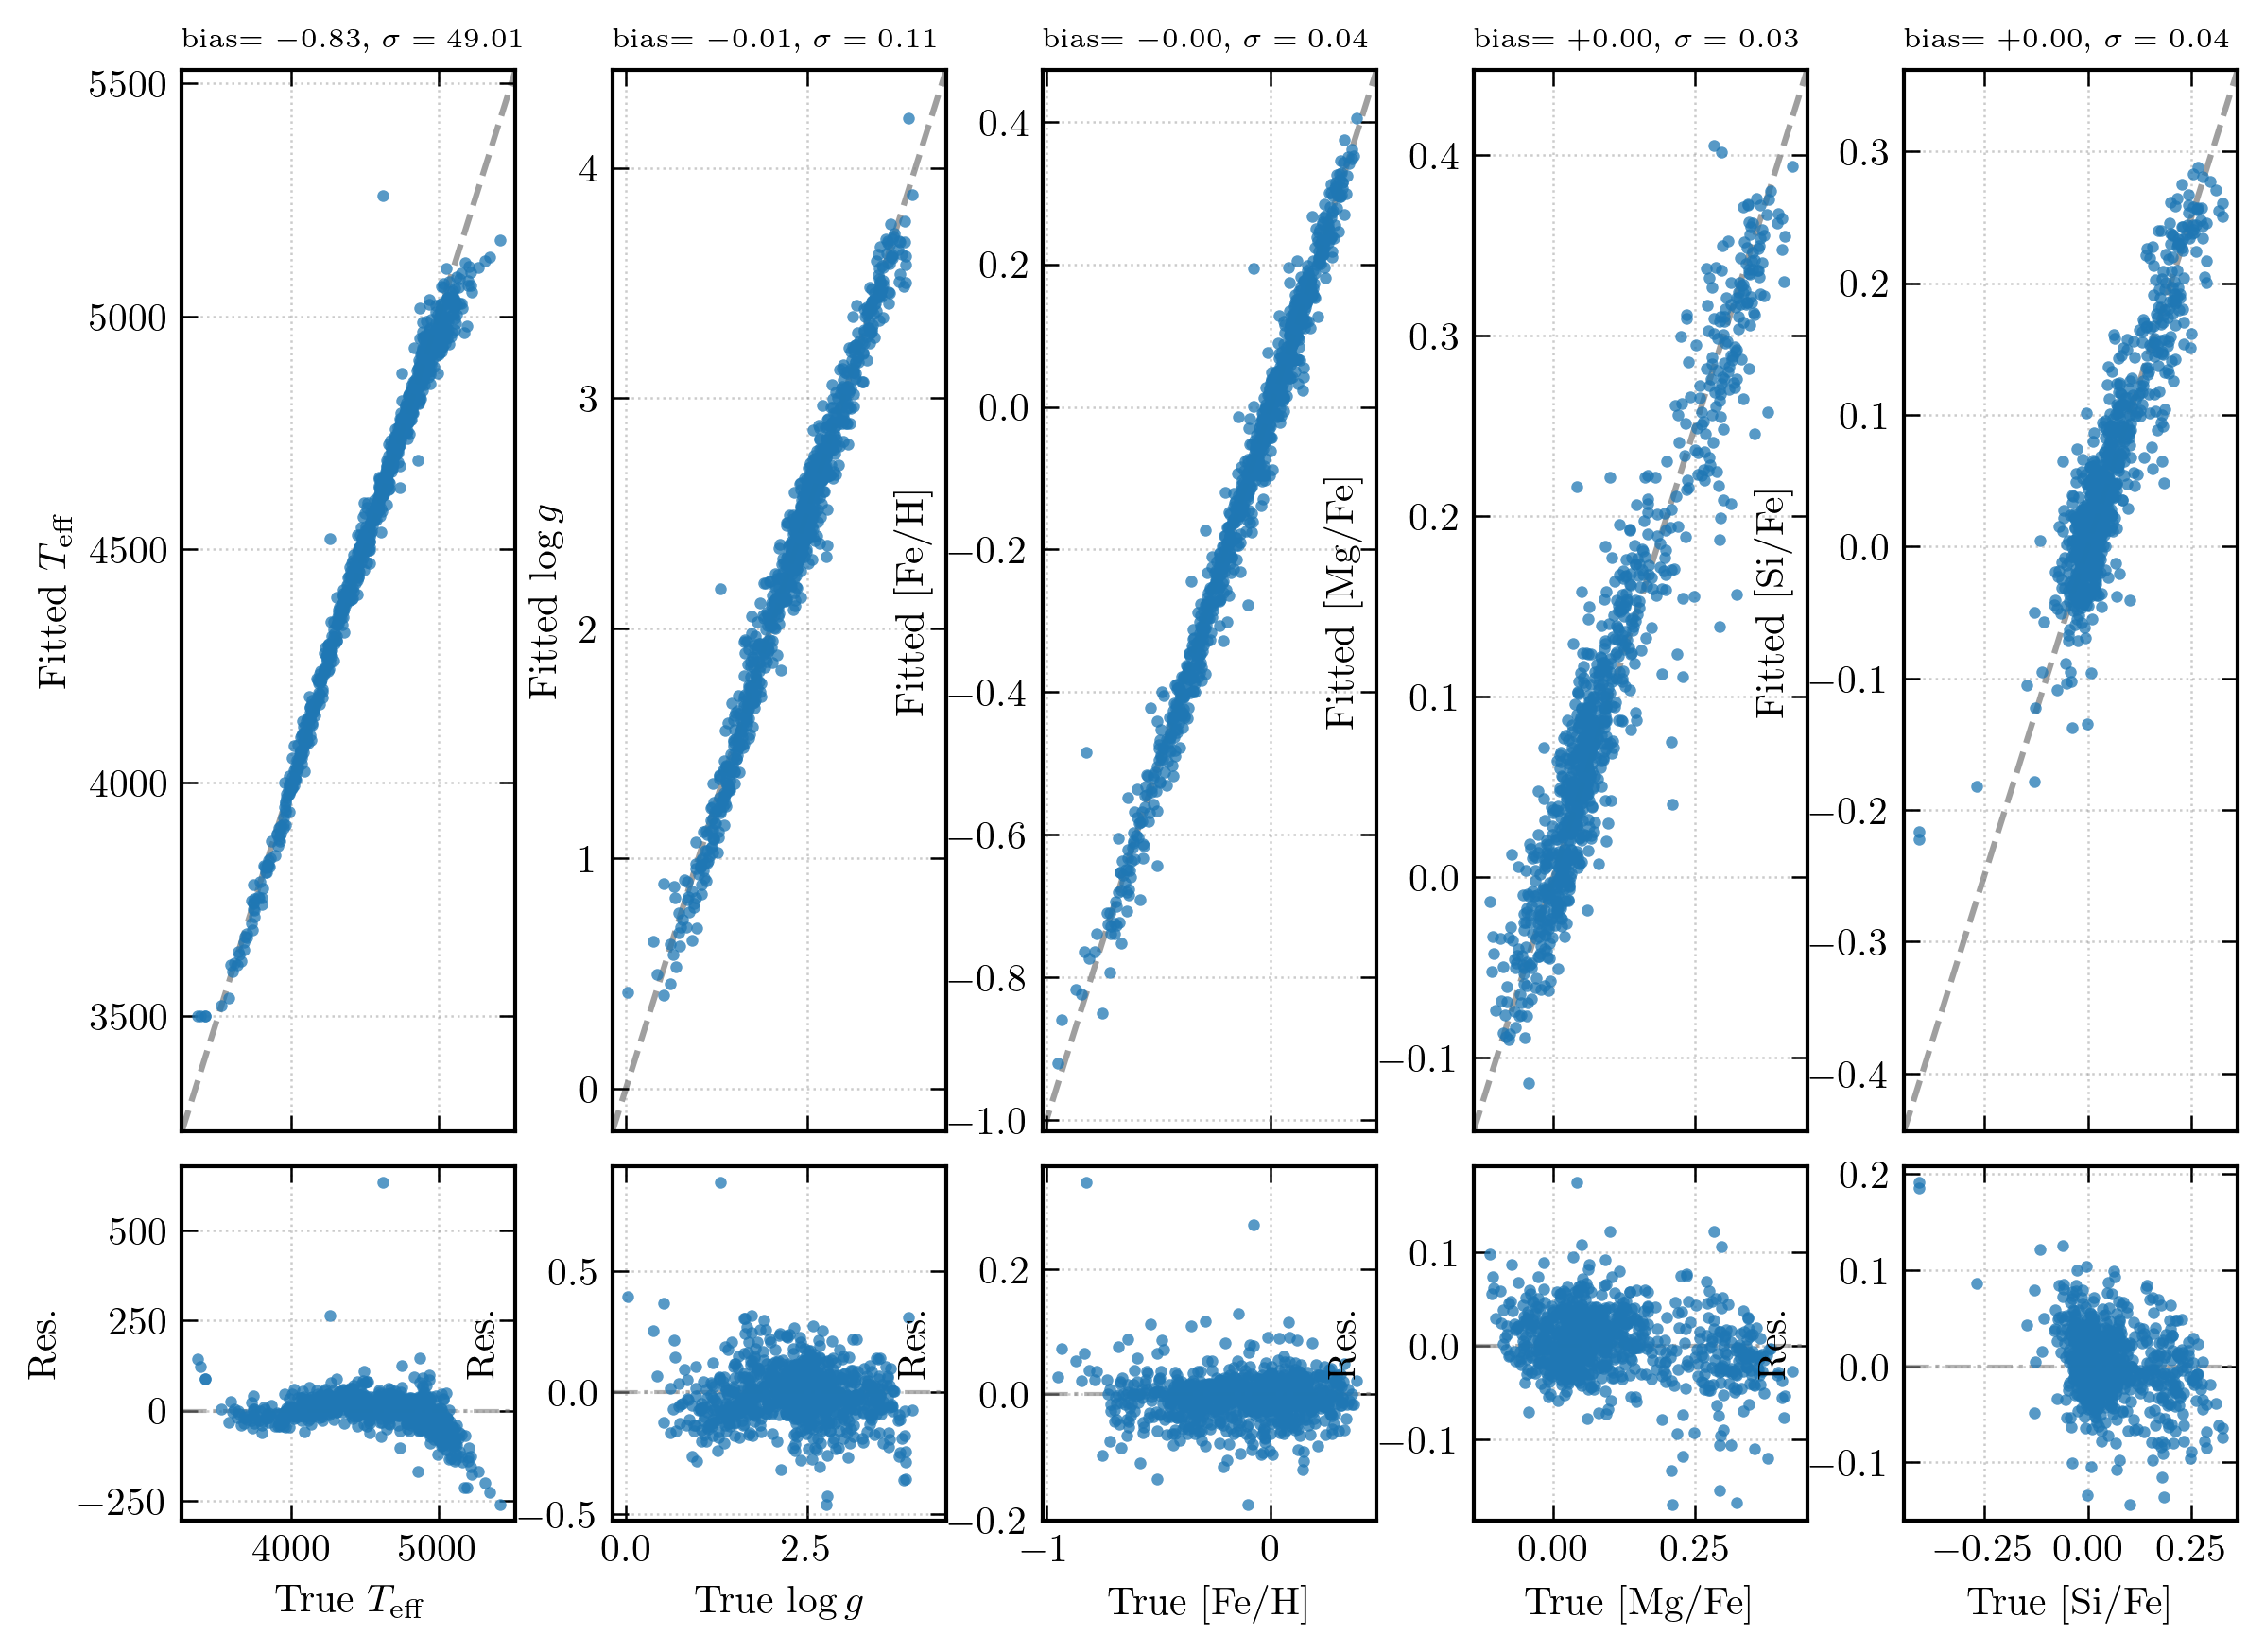

In [9]:
axes = plotters.plot_label_recovery(labels[cv_idx_clean], fitted_clean, LABEL_LATEX)
plt.show()

## Problem 10 — Outlier Investigation

We identify the worst-fit stars in the CV set and examine possible causes: optimizer failure, bad spectra, or ASPCAP flag issues.

In [10]:
# Identify worst-fit stars in the CLEAN CV set
label_stds_cv = np.std(labels[cv_idx_clean], axis=0)
label_stds_cv[label_stds_cv == 0] = 1.0
norm_resid = np.sqrt(np.sum((residuals_clean / label_stds_cv) ** 2, axis=1))
worst_idx = np.argsort(norm_resid)[-5:][::-1]

ids_cv_clean = apogee_ids[cv_idx_clean]
print("Worst-fit CV stars (after outlier rejection):")
for i, idx in enumerate(worst_idx):
    print(f"  {i+1}. {ids_cv_clean[idx]}: normalized residual = {norm_resid[idx]:.2f}")
    print(f"     True:   {labels[cv_idx_clean][idx]}")
    print(f"     Fitted: {fitted_clean[idx]}")
    print(f"     Diff:   {residuals_clean[idx]}")

Worst-fit CV stars (after outlier rejection):
  1. 2M19430701+2500284: normalized residual = 2.38
     True:   [ 4.945970e+03  2.787612e+00  1.428000e-01 -1.067670e-01 -4.072194e-01]
     Fitted: [ 4.85539768e+03  2.66384252e+00  2.33094080e-02 -3.26629241e-02
 -2.16418521e-01]
     Diff:   [-9.05723190e+01 -1.23769476e-01 -1.19490592e-01  7.41040759e-02
  1.90800879e-01]
  2. 2M19432222+2444530: normalized residual = 2.27
     True:   [ 4.919759e+03  2.590224e+00 -2.813500e-02 -4.112899e-02 -4.071914e-01]
     Fitted: [ 4.94676312e+03  2.86255529e+00 -7.18208518e-02  1.87318359e-02
 -2.22075828e-01]
     Diff:   [27.00412475  0.27233129 -0.04368585  0.05986083  0.18511557]
  3. 2M21261328+1139054: normalized residual = 2.25
     True:   [ 4.624948e+03  3.904589e+00 -7.540200e-02 -1.043345e-01  4.888300e-02]
     Fitted: [ 5.25870420e+03  4.21385090e+00  1.94323011e-01 -4.23793422e-02
 -2.35556012e-02]
     Diff:   [ 6.33756204e+02  3.09261895e-01  2.69725011e-01  6.19551578e-02
 -7.24

In [11]:
# Check if fitted labels ≈ initial guess (optimizer stuck at mean)
stuck_threshold = 0.01  # labels within 1% of mean in scaled space
scaled_fitted = (fitted_clean[worst_idx] - model_clean.label_means) / model_clean.label_stds
stuck = np.all(np.abs(scaled_fitted) < stuck_threshold, axis=1)
for i, (idx, is_stuck) in enumerate(zip(worst_idx, stuck)):
    status = "STUCK at mean" if is_stuck else "converged (not stuck)"
    print(f"  {ids_cv_clean[idx]}: {status}")

  2M19430701+2500284: converged (not stuck)
  2M19432222+2444530: converged (not stuck)
  2M21261328+1139054: converged (not stuck)
  2M21331710+1156173: converged (not stuck)
  2M03560370+2553554: converged (not stuck)


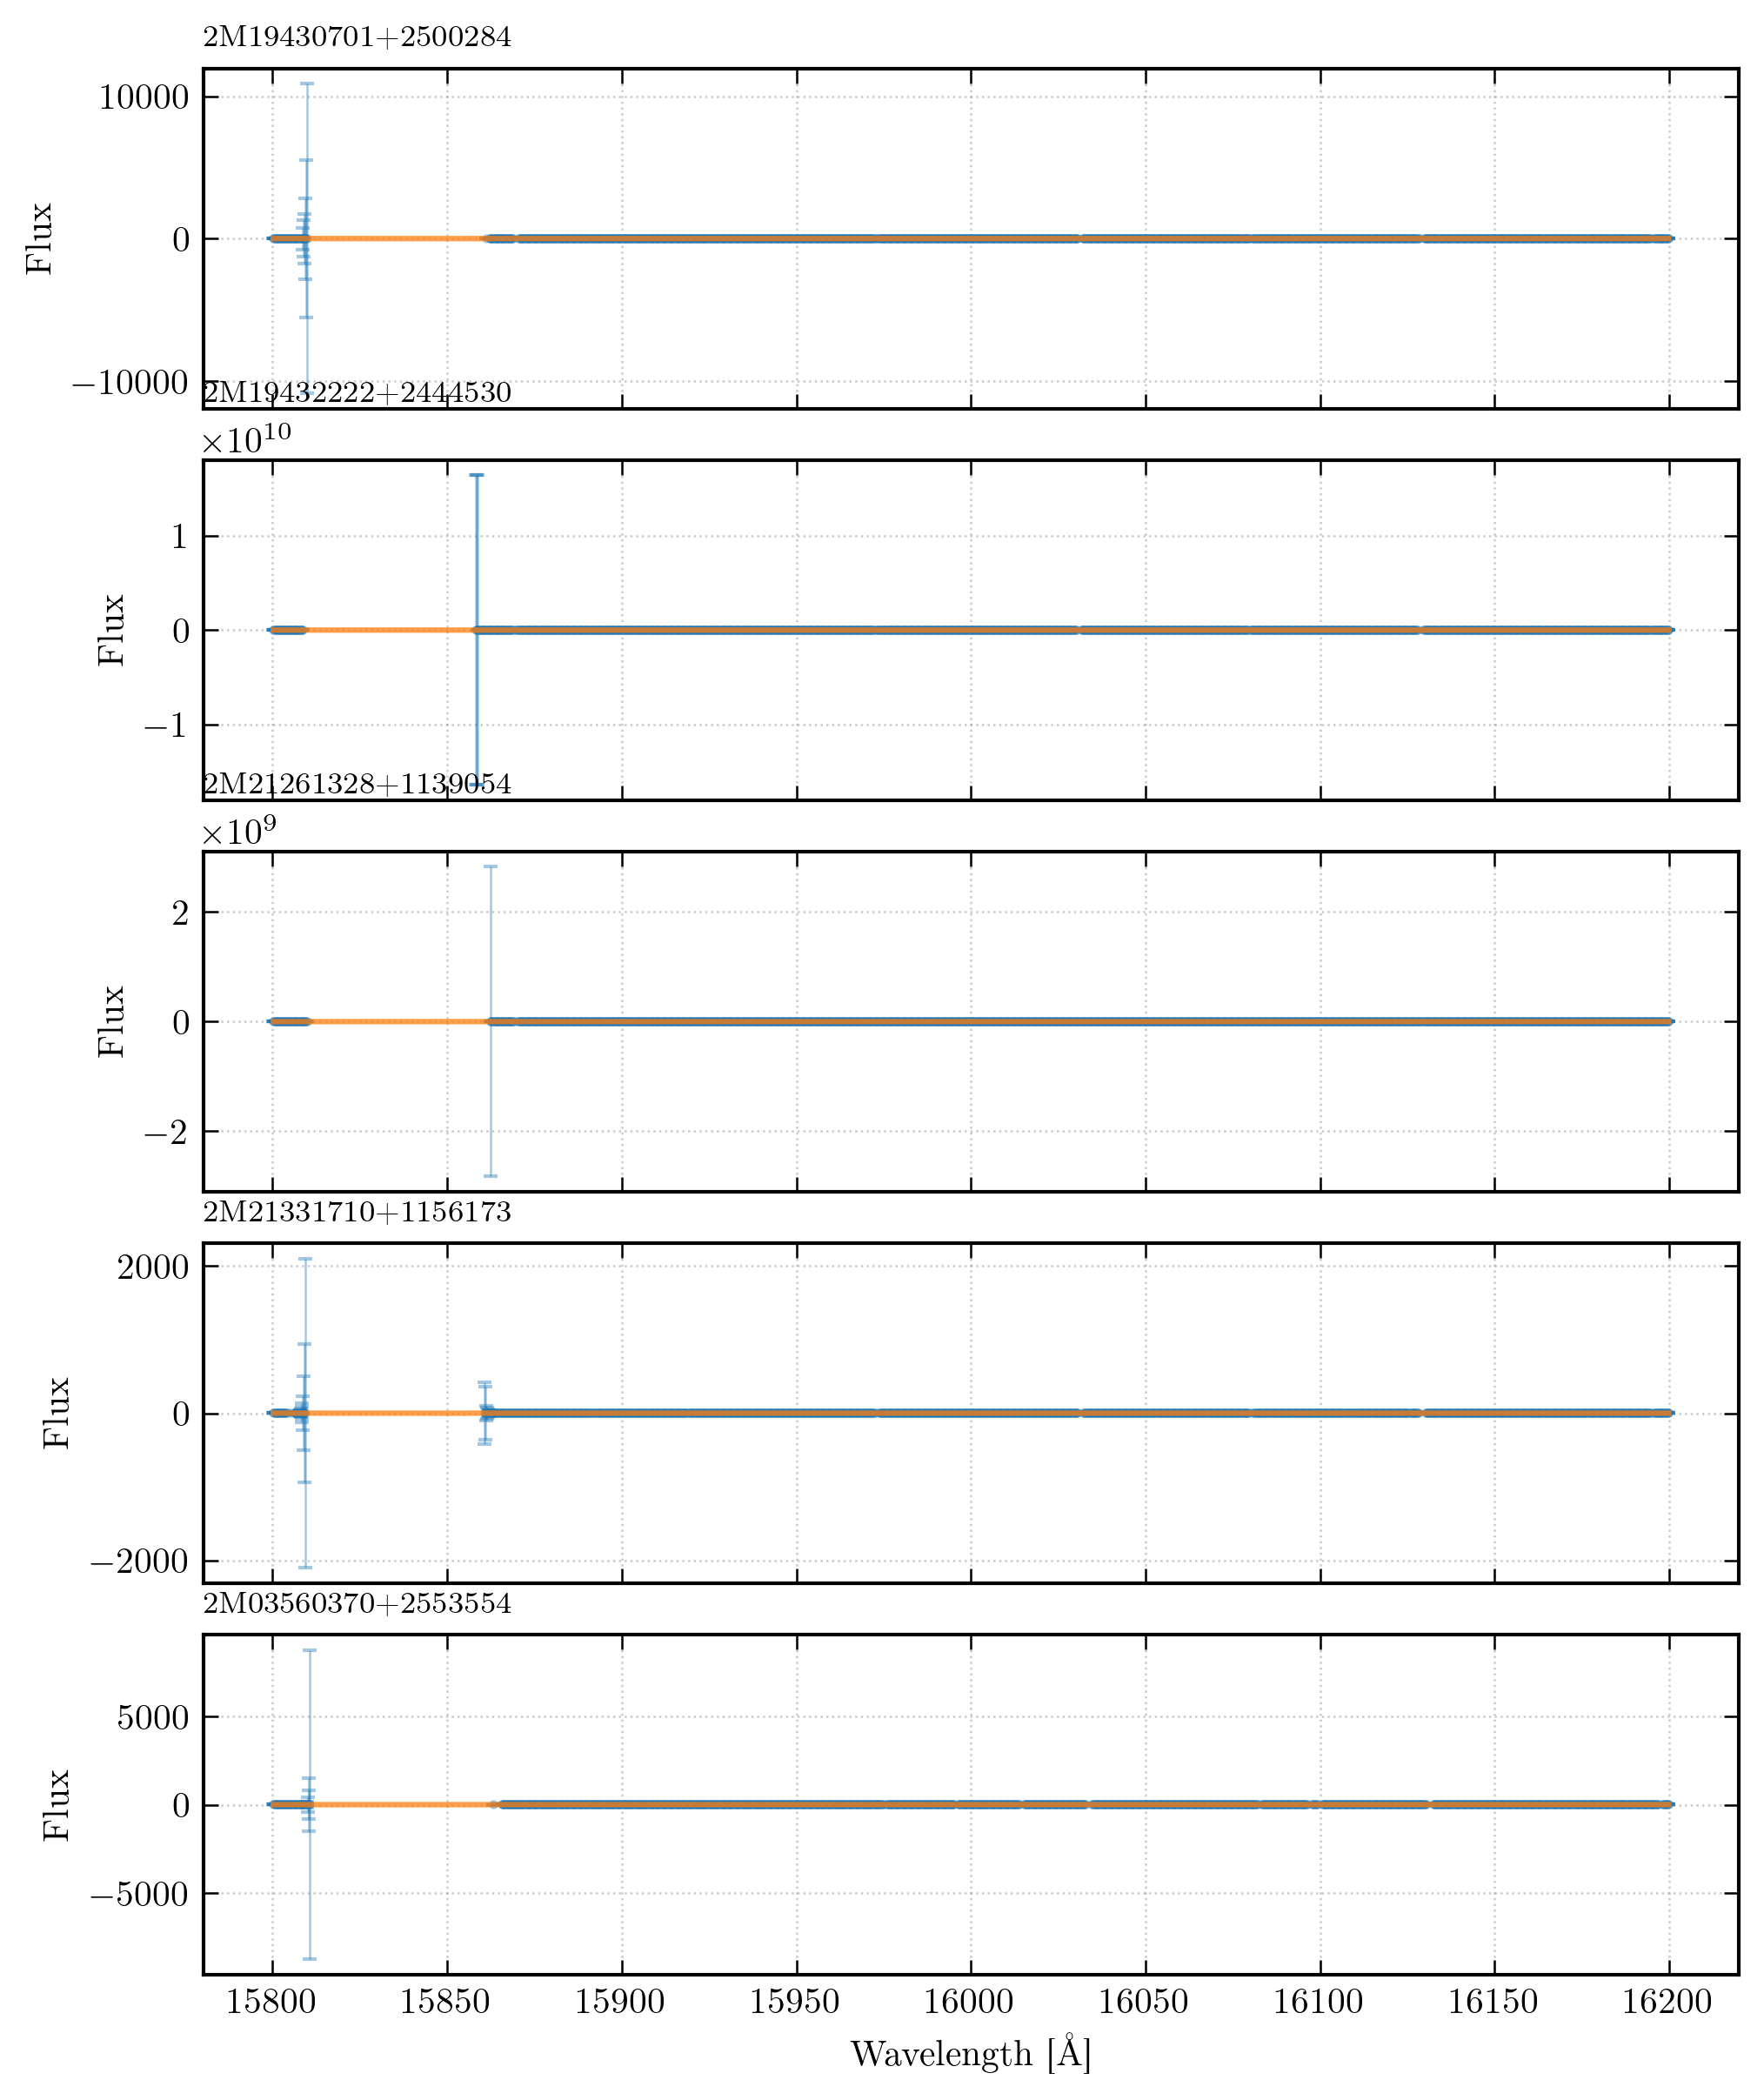

In [12]:
# Plot outlier spectra
flux_pred_worst = np.array([model_clean.predict(fitted_clean[idx]) for idx in worst_idx])

axes = plotters.plot_outlier_spectra(
    wavelength, flux[cv_idx_clean][worst_idx], error[cv_idx_clean][worst_idx],
    flux_pred_worst, ids_cv_clean[worst_idx],
)
plt.show()

In [13]:
# Check ASPCAP flags for outliers
starflag_cv_clean = starflag[cv_idx_clean]
aspcapflag_cv_clean = aspcapflag[cv_idx_clean]

print("ASPCAP flags for outlier stars:")
for idx in worst_idx:
    print(f"  {ids_cv_clean[idx]}: starflag={starflag_cv_clean[idx]:#010x}, "
          f"aspcapflag={aspcapflag_cv_clean[idx]:#010x}")

ASPCAP flags for outlier stars:
  2M19430701+2500284: starflag=0x00000804, aspcapflag=0x00000004
  2M19432222+2444530: starflag=0x00000804, aspcapflag=0x00000040
  2M21261328+1139054: starflag=0x00001200, aspcapflag=0x00000004
  2M21331710+1156173: starflag=0x00000000, aspcapflag=0x00000044
  2M03560370+2553554: starflag=0x00000000, aspcapflag=0x00000004


In [14]:
# Check continuum normalization quality for outliers
continuum_mask = spec_data["continuum_mask"].astype(bool)

print("Continuum normalization quality for outlier stars:")
print(f"  {'ID':<25s} {'Mean cont px':>12s} {'Std cont px':>12s} {'% inf err':>10s}")
for idx in worst_idx:
    f_cont = flux[cv_idx_clean][idx, continuum_mask]
    e_cont = error[cv_idx_clean][idx, continuum_mask]
    valid = np.isfinite(f_cont) & (e_cont < np.inf)
    frac_inf = 1.0 - np.sum(valid) / len(f_cont)
    if np.sum(valid) > 0:
        print(f"  {ids_cv_clean[idx]:<25s} {np.mean(f_cont[valid]):>12.4f} "
              f"{np.std(f_cont[valid]):>12.4f} {100*frac_inf:>9.1f}%")
    else:
        print(f"  {ids_cv_clean[idx]:<25s} {'N/A':>12s} {'N/A':>12s} {100*frac_inf:>9.1f}%")

Continuum normalization quality for outlier stars:
  ID                        Mean cont px  Std cont px  % inf err
  2M19430701+2500284              1.0002       0.0172       0.2%
  2M19432222+2444530              1.0007       0.0165       0.0%
  2M21261328+1139054              1.0019       0.0245       0.0%
  2M21331710+1156173              1.0013       0.0130       0.9%
  2M03560370+2553554              1.0007       0.0110       1.9%


Outlier stars may have non-zero `starflag` or `aspcapflag` values indicating warnings from the ASPCAP pipeline (e.g., low SNR in certain wavelength regions, unreliable abundance determinations, or issues with the RV combination of visits). Stars with significant flag bits may have less reliable ASPCAP labels, making them poor reference points for evaluating the Cannon's performance.

For continuum normalization: if the mean of continuum pixels deviates significantly from 1.0, or if the fraction of masked (`inf` error) pixels is unusually high, the normalization may have failed for that star. Poor normalization would introduce systematic biases in all fitted labels.

For stars where the optimizer converged away from the initial guess, the Cannon fit is meaningful but the ASPCAP reference labels themselves may be inaccurate.

## Problem 11 — Kiel Diagram

### MIST isochrones

We retrieve MIST isochrones at $[\mathrm{Fe/H}] = 0$ and $[\mathrm{Fe/H}] = -1$ (age = 6 Gyr) to overlay on the Kiel diagram.

In [15]:
iso_solar = _get_mist_isochrone(6.0, 0.0)
iso_metal_poor = _get_mist_isochrone(6.0, -1.0)

print(f"[Fe/H]=0 isochrone: {len(iso_solar)} points, "
      f"Teff range {iso_solar['Teff'].min():.0f}–{iso_solar['Teff'].max():.0f} K")
print(f"[Fe/H]=-1 isochrone: {len(iso_metal_poor)} points, "
      f"Teff range {iso_metal_poor['Teff'].min():.0f}–{iso_metal_poor['Teff'].max():.0f} K")

Holoviews not imported. Some visualizations will not be available.
PyMultiNest not imported.  MultiNest fits will not work.


[Fe/H]=0 isochrone: 1468 points, Teff range 2651–128120 K
[Fe/H]=-1 isochrone: 1476 points, Teff range 3378–128175 K


### Kiel diagram

The Kiel diagram ($\log g$ vs $T_{\rm eff}$) reveals evolutionary structure. With both axes inverted (hot→cold left→right, low gravity at top), the red giant branch (RGB) rises from the lower right. The red clump (core He burning) forms a dense concentration near $T_{\rm eff} \sim 4800$ K, $\log g \sim 2.5$. Color-coding by $[\mathrm{Fe/H}]$ shows that more metal-rich stars are cooler at fixed $\log g$, consistent with the effect of increased opacity on stellar structure.

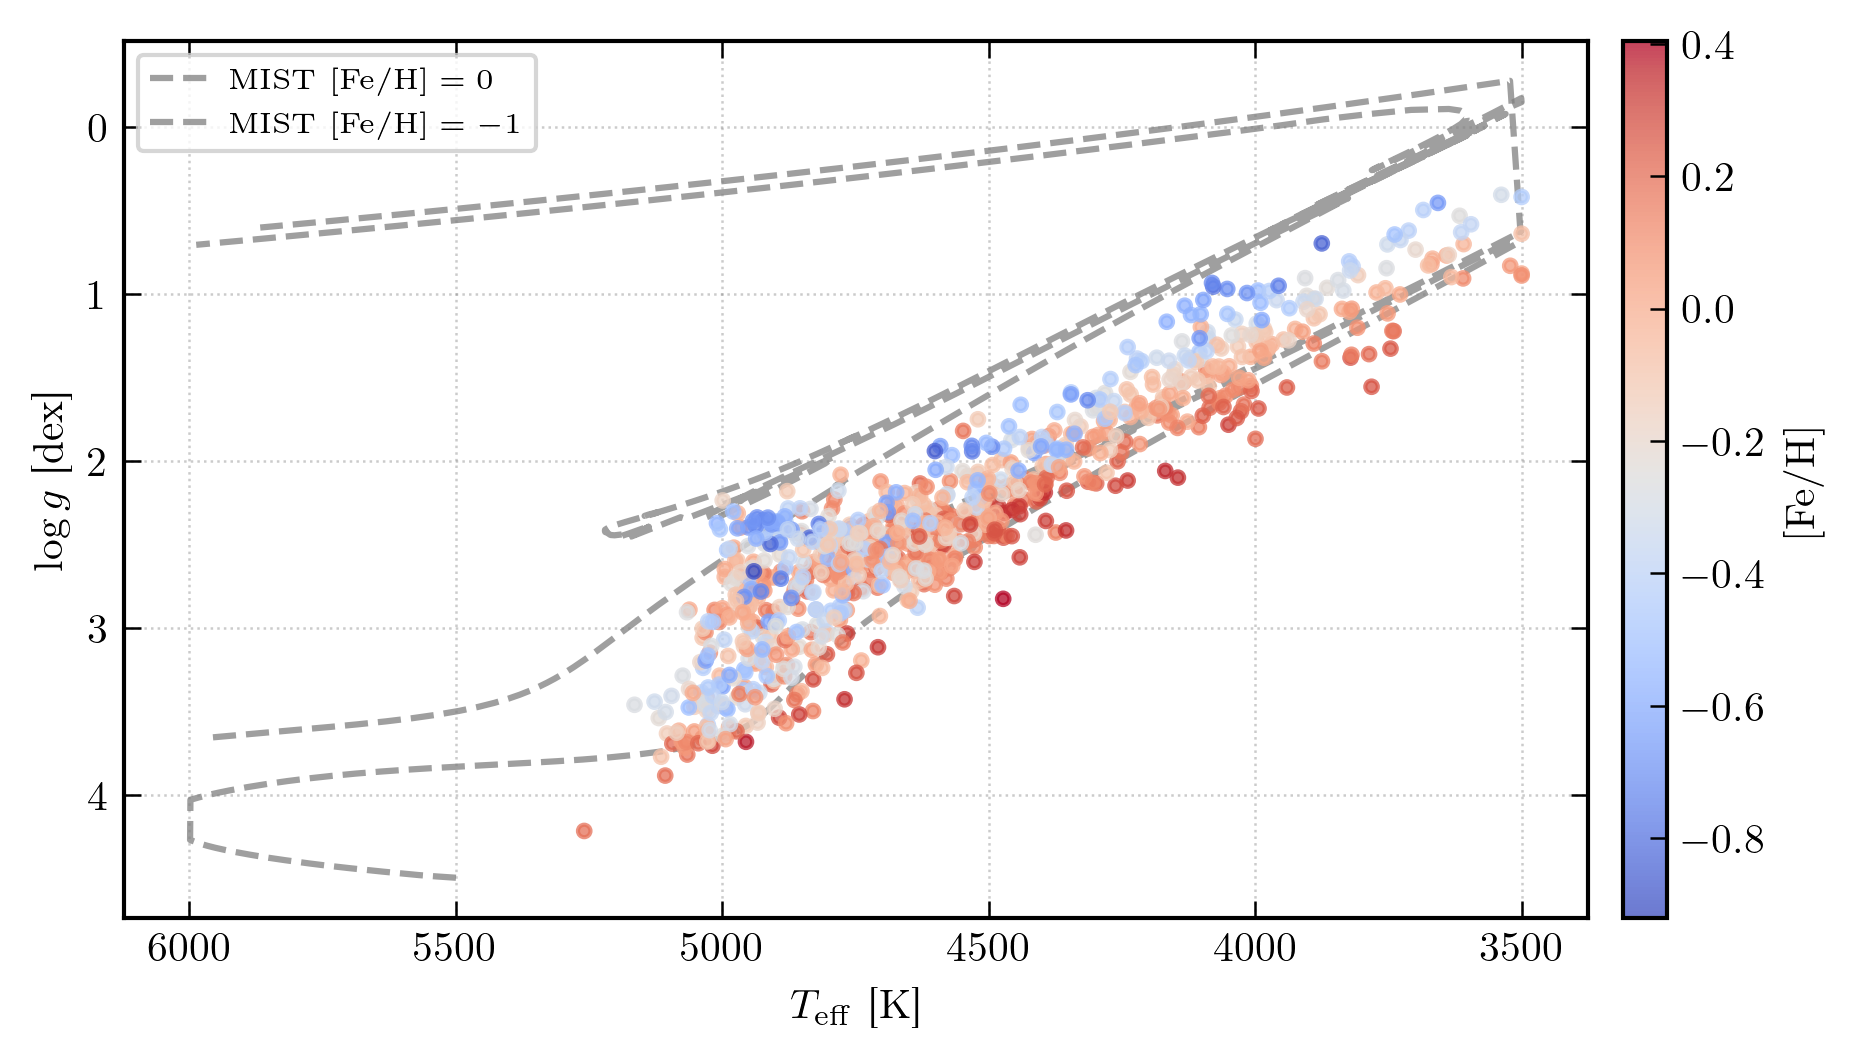

In [16]:
isochrone_tracks = [
    (r"MIST $[\mathrm{Fe/H}]=0$", iso_solar),
    (r"MIST $[\mathrm{Fe/H}]=-1$", iso_metal_poor),
]

ax = plotters.plot_kiel_diagram(fitted_clean, LABEL_NAMES, isochrone_tracks)
plt.show()

### Save cross-validation results

In [17]:
# Save the cleaned model (overwrites NB 02's version)
np.savez_compressed(
    "cannon_model.npz",
    theta=model_clean.theta,
    scatter=model_clean.scatter,
    label_means=model_clean.label_means,
    label_stds=model_clean.label_stds,
    wavelength=model_clean.wavelength,
    label_names=np.array(model_clean.label_names),
    chi2_r=np.array(model_clean.chi2_r),
    train_idx=train_idx_clean,
    cv_idx=cv_idx_clean,
)
print("Saved cannon_model.npz (clean)")
print(f"  theta: {model_clean.theta.shape}")
print(f"  chi2_r: {model_clean.chi2_r:.3f}")
print(f"  train_idx: {train_idx_clean.shape}, cv_idx: {cv_idx_clean.shape}")

# Save clean CV results
np.savez_compressed(
    "cv_results.npz",
    fitted_labels=fitted_clean,
    true_labels=labels[cv_idx_clean],
    apogee_ids_cv=apogee_ids[cv_idx_clean],
)
print("Saved cv_results.npz (clean)")
print(f"  fitted_labels: {fitted_clean.shape}")
print(f"  true_labels: {labels[cv_idx_clean].shape}")

Saved cannon_model.npz (clean)
  theta: (8575, 21)
  chi2_r: 1.060
  train_idx: (897,), cv_idx: (897,)
Saved cv_results.npz (clean)
  fitted_labels: (897, 5)
  true_labels: (897, 5)
